In [112]:
import warnings
warnings.filterwarnings('ignore')

In [113]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [114]:
df = pd.read_csv('../data/cervical_cancer.csv')

In [115]:
df.head()

,Age,Number of sexual partners,First sexual intercourse,Num of pregnancies,Smokes,Smokes (years),Smokes (packs/year),Hormonal Contraceptives,Hormonal Contraceptives (years),IUD,...,STDs: Time since first diagnosis,STDs: Time since last diagnosis,Dx:Cancer,Dx:CIN,Dx:HPV,Dx,Hinselmann,Schiller,Citology,Biopsy
0,18,4.0,15.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,?,?,0,0,0,0,0,0,0,0
1,15,1.0,14.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,?,?,0,0,0,0,0,0,0,0
2,34,1.0,?,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,?,?,0,0,0,0,0,0,0,0
3,52,5.0,16.0,4.0,1.0,37.0,37.0,1.0,3.0,0.0,...,?,?,1,0,1,0,0,0,0,0
4,46,3.0,21.0,4.0,0.0,0.0,0.0,1.0,15.0,0.0,...,?,?,0,0,0,0,0,0,0,0


In [116]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 858 entries, 0 to 857
Data columns (total 36 columns):
 #   Column                              Non-Null Count  Dtype 
---  ------                              --------------  ----- 
 0   Age                                 858 non-null    int64 
 1   Number of sexual partners           858 non-null    object
 2   First sexual intercourse            858 non-null    object
 3   Num of pregnancies                  858 non-null    object
 4   Smokes                              858 non-null    object
 5   Smokes (years)                      858 non-null    object
 6   Smokes (packs/year)                 858 non-null    object
 7   Hormonal Contraceptives             858 non-null    object
 8   Hormonal Contraceptives (years)     858 non-null    object
 9   IUD                                 858 non-null    object
 10  IUD (years)                         858 non-null    object
 11  STDs                                858 non-null    object

In [117]:
def unique_values_df(df: pd.DataFrame):

    for col in list(df):
        print(f"{col}: {df[col].nunique()}")
        print('dtype for {} is: {}'.format(str(col) ,df[col].dtype))
        print('---'*100)

def unique_values_col(df:pd.DataFrame,col_names:list[str] = None):

    for col in  col_names:
        print("Unique Values for "'{}'":{}".format(str(col),df[col].unique()))


In [118]:
unique_values_df(df)

Age: 44
dtype for Age is: int64
------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
Number of sexual partners: 13
dtype for Number of sexual partners is: object
------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
First sexual intercourse: 22
dtype for First sexual intercourse is: object
----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------

In [119]:
cols_to_convert = ['Number of sexual partners', 'First sexual intercourse', 'Num of pregnancies', 'Smokes',
                   'Smokes (years)', 'Smokes (packs/year)', 'Hormonal Contraceptives',
                   'Hormonal Contraceptives (years)', 'IUD', 'IUD (years)', 'STDs', 'STDs (number)',
                   'STDs:condylomatosis', 'STDs:cervical condylomatosis', 'STDs:vaginal condylomatosis',
                   'STDs:vulvo-perineal condylomatosis', 'STDs:syphilis', 'STDs:pelvic inflammatory disease',
                   'STDs:genital herpes', 'STDs:molluscum contagiosum', 'STDs:AIDS', 'STDs:HIV', 'STDs:Hepatitis B',
                   'STDs:HPV', 'STDs: Time since first diagnosis',
                   'STDs: Time since last diagnosis']

In [120]:
from sklearn.impute import SimpleImputer

In [121]:
df[cols_to_convert] = df[cols_to_convert].apply(pd.to_numeric,errors='coerce')
df[cols_to_convert].fillna(np.nan,inplace=True)

imp = SimpleImputer(strategy='median')
X=imp.fit_transform(df)
df = pd.DataFrame(X,columns=list(df.columns))

In [122]:
def age_cat(age):
    if age < 12:
        return "Child"
    elif age < 20:
        return "Teen"
    elif age < 30:
        return "20's"
    elif age < 40:
        return "30's"
    elif age < 50:
        return "40's"
    elif age < 60:
        return "50's"
    elif age < 70:
        return "60's"
    else:
        return "70+"


In [123]:
df['Age'] = df['Age'].astype(int)
df['age_cat'] = df['Age'].apply(age_cat)

In [124]:
std_cols = {'STDs:condylomatosis',
            'STDs:cervical condylomatosis',
            'STDs:vaginal condylomatosis',
            'STDs:vulvo-perineal condylomatosis',
            'STDs:syphilis',
            'STDs:pelvic inflammatory disease',
            'STDs:genital herpes',
            'STDs:molluscum contagiosum',
            'STDs:AIDS',
            'STDs:HIV',
            'STDs:Hepatitis B',
            'STDs:HPV'}

In [125]:
df['total_std'] = df[list(std_cols)].sum(axis=1)
std_agg = df.groupby('age_cat',as_index=False)[list(std_cols)].sum()

In [126]:
test_cols = ["Hinselmann", "Schiller", "Citology", "Biopsy"]
df['total_tests'] = df[test_cols].sum(axis=1)

In [127]:
to_int_and_beyond = {"total_tests",
                     "total_std",
                     "Smokes",
                     "Biopsy",
                     "Dx:Cancer",
                     "Num of pregnancies",
                     "Number of sexual partners",
                     "First sexual intercourse",
                     "Hormonal Contraceptives",
                     "IUD",
                     "STDs",
                     "STDs (number)",
                     "STDs: Number of diagnosis",
                     "Dx:CIN",
                     "Dx:HPV",
                     "Dx",
                     "Hinselmann",
                     "Schiller",
                     "Biopsy",
                     "Citology"}
                    

In [128]:
to_int_and_beyond = to_int_and_beyond.union(std_cols)

In [129]:
for col in to_int_and_beyond:
    df[col] = df[col].astype(int)

In [130]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 858 entries, 0 to 857
Data columns (total 39 columns):
 #   Column                              Non-Null Count  Dtype  
---  ------                              --------------  -----  
 0   Age                                 858 non-null    int64  
 1   Number of sexual partners           858 non-null    int64  
 2   First sexual intercourse            858 non-null    int64  
 3   Num of pregnancies                  858 non-null    int64  
 4   Smokes                              858 non-null    int64  
 5   Smokes (years)                      858 non-null    float64
 6   Smokes (packs/year)                 858 non-null    float64
 7   Hormonal Contraceptives             858 non-null    int64  
 8   Hormonal Contraceptives (years)     858 non-null    float64
 9   IUD                                 858 non-null    int64  
 10  IUD (years)                         858 non-null    float64
 11  STDs                                858 non-n

In [131]:
n = 7
target = "Dx:Cancer"
corr = df.select_dtypes(include=np.number).corr()

In [132]:
x = corr.nlargest(n,target).index
corr_df = df[list(x)]
corr = corr_df.corr()


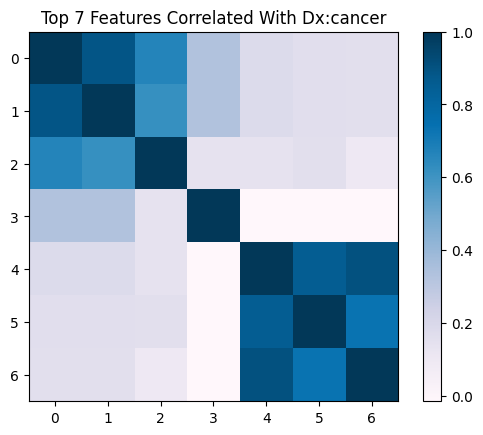

In [133]:
plt.imshow(corr, cmap="PuBu")
plt.title("Top " + str(n) + " Features Correlated With " + str(target).capitalize())
plt.colorbar()
plt.show()

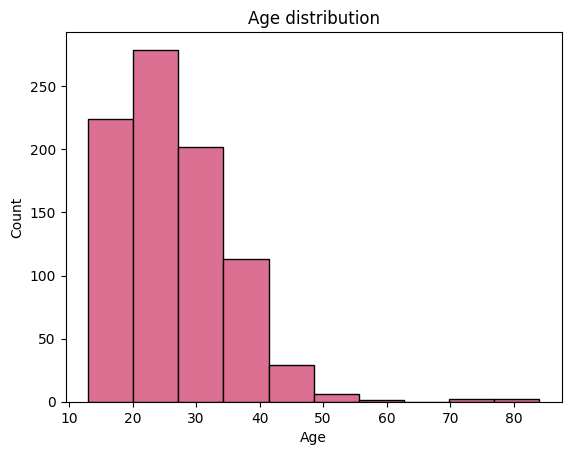

In [134]:
plt.hist(df["Age"], color="palevioletred", edgecolor="black")
plt.title("Age distribution")
plt.xlabel("Age")
plt.ylabel("Count")
plt.show()

In [135]:
import plotly.express as px

In [136]:
age_preg_bar = px.box(
    df.sort_values(by='Age', ascending=True),
    x='age_cat',
    y='Num of pregnancies',
    color_discrete_sequence=['darkblue'],
    points='outliers',
    category_orders={
        "age_cat": ["Teenager", "Twenties", "Thirties", "Forties", "Fifties", "Seventy and over"]
    }
)
age_preg_bar.update_xaxes(title="Age Category")
age_preg_bar.update_yaxes(title="Number of Pregnancies")
age_preg_bar.update_layout(title="Distribution of number of pregnancies per age group")
age_preg_bar.show()

In [137]:
age_num_sex_partners = px.box(df.sort_values(by="Age",ascending=True), x="age_cat", y="Number of sexual partners",
                      color_discrete_sequence=["blue"], points="outliers",
                      category_orders=["Teenager", "Twenties", "Thirties", "Forties", "Fifties",
                                       "Seventy and over"])
age_num_sex_partners.update_xaxes(title="Age Category")
age_num_sex_partners.update_yaxes(title="Number of Sexual Partners")
age_num_sex_partners.update_layout(title="Distribution of number of sexual partners per age group")
age_num_sex_partners.show()

In [138]:
age_num_sex_partners = px.scatter(df, x="Age",
                                  y="Number of sexual partners",
                                  trendline="ols",
                                  opacity=0.4,
                                  color="Num of pregnancies",
                                  color_continuous_scale="rdbu",)
age_num_sex_partners.update_layout(title="Age vs Number of Sexual Partners")
age_num_sex_partners.show()

In [139]:
diagnoses_num_partner_compare_cols = ['Dx:Cancer',
                                      'Dx:HPV',
                                      "Number of sexual partners",]
corr_matrix = df[diagnoses_num_partner_compare_cols].corr()
print(corr_matrix)
diagnoses_num_partner_heatmap = px.imshow(corr_matrix,
                              aspect="auto",
                              color_continuous_scale="gnbu",
                              text_auto=True)
diagnoses_num_partner_heatmap.show()

                           Dx:Cancer    Dx:HPV  Number of sexual partners
Dx:Cancer                   1.000000  0.886508                   0.023699
Dx:HPV                      0.886508  1.000000                   0.028646
Number of sexual partners   0.023699  0.028646                   1.000000


In [140]:
diagnoses_cols = ['Dx:Cancer',
                  'Dx:CIN',
                  'Dx:HPV']
diagnoses_corr_matrix = df[diagnoses_cols].corr()
# print(diagnoses_corr_matrix)
diagnoses_heatmap = px.imshow(diagnoses_corr_matrix, aspect="auto", color_continuous_scale="tealgrn", text_auto=True)
diagnoses_heatmap.show()

In [141]:
fig = px.histogram(std_agg, x="age_cat", y=list(std_cols), barmode="group", histfunc="sum")
fig.update_layout(title="Sum of STD occurence across age categories")
fig.update_xaxes(title="Age Category")
fig.update_yaxes(title="Sum")
fig.show()

In [142]:
fig = px.histogram(df.query("total_std>=0").sort_values(by=["total_std", "Dx:Cancer"], ascending=True),
                   x="age_cat",
                   facet_col="total_std",
                   facet_row="Dx:Cancer",
                   color_discrete_sequence=["rebeccapurple"],
                   opacity=0.7)
fig.update_layout(title="Count of women across age groups who have had one or more std")

fig.show()

In [143]:
fig = px.histogram(df.query("total_std>=0").sort_values(by=["total_std","Dx:HPV"], ascending=True),
                   x="age_cat",
                   facet_col="total_std",
                   facet_row="Dx:HPV",
                   color_discrete_sequence=["dodgerblue"],
                   opacity=0.7)
fig.update_layout(title="Count of women across age groups who have had one or more std")

fig.show()

In [144]:
fig = px.histogram(df.query("total_tests>0").sort_values(by="total_tests", ascending=True),
                   x="age_cat",
                   facet_col="total_tests",
                   facet_row="Dx:Cancer",
                   color_discrete_sequence=["blueviolet"],
                   opacity=0.8)
fig.update_layout(title="Count of women across age groups who have had one or more test")

fig.show()

In [145]:
fig = px.histogram(df.query("total_tests>0").sort_values(by=["total_tests","Dx:HPV"], ascending=True),
                   x="age_cat",
                   facet_col="total_tests",
                   facet_row="Dx:HPV",
                   color_discrete_sequence=["coral"],
                   opacity=0.8)
fig.update_layout(title="Count of women across age groups who have had one or more test")

fig.show()

In [146]:
fig = px.ecdf(df, x=["Smokes (years)",
                                 "Hormonal Contraceptives (years)",
                                 "IUD (years)"],
              color_discrete_sequence=["crimson", "deepskyblue", "chartreuse"])
fig.update_xaxes(title="Years")
fig.update_layout(title="ECDF Plot")
fig.show()

In [147]:
age_category_range = {
    "Age<12": "Child",
    "Age>=12 & Age<20": "Teen",
    "Age>=20 & Age<30": "20's",
    "Age>=30 & Age<40": "30's",
    "Age>=40 & Age<50": "40's",
    "Age>=50 & Age<60": "50's",
    "Age>=60 & Age<70": "60's",
    "Age>=70": "70+"}

In [148]:
age_prop_dict = {}

In [149]:
col = "Age" 
for age_range, category in age_category_range.items():
    age_prop_dict[category] = df.query(age_range)[col].count() / len(df)

In [150]:
proportion_samples_df = pd.DataFrame.from_dict(age_prop_dict, orient="index",
                                               columns=[ "Sample Proportion"])

In [151]:
proportion_samples_df = proportion_samples_df.reset_index()
proportion_samples_df.columns = proportion_samples_df.columns.str.replace("index","Category")
fig = px.pie(proportion_samples_df,
             values='Sample Proportion',
             names="Category",
             title='Age Category proportion of women sampled',color_discrete_sequence=px.colors.sequential.Magenta)
fig.show()
proportion_samples_df

,Category,Sample Proportion
0,Child,0.000000
1,Teen,0.208625
2,20's,0.459207
3,30's,0.256410
4,40's,0.065268
5,50's,0.005828
6,60's,0.000000
7,70+,0.004662


In [152]:
import plotly.graph_objects as go
from plotly.subplots import make_subplots

In [153]:
fig = make_subplots(rows=1, cols=2, specs=[[{'type': 'domain'}, {'type': 'domain'}]],
                    subplot_titles=["Cancer", "HPV"])
fig.add_trace(go.Pie(labels=df["age_cat"],
                     values=df["Dx:Cancer"],
                     name="Cancer", marker_colors=px.colors.sequential.RdBu),
              1, 1)

fig.add_trace(go.Pie(labels=df["age_cat"],
                     values=df["Dx:HPV"],
                     name="HPV", marker_colors=px.colors.sequential.RdBu),
              1, 2)
              
fig.update_traces(hole=.0, hoverinfo="label+percent+name")

fig.update_layout(
    title_text="Proportion of women across age categories with a diagnosis of Cancer, HPV",
)
fig.show()

In [154]:
df_hormonal_compariosn = df.groupby(["age_cat"], as_index=False)[["IUD", "Hormonal Contraceptives"]].sum()
fig = px.histogram(df_hormonal_compariosn, x="age_cat", y=["IUD", "Hormonal Contraceptives"], barmode="group"
                   , color_discrete_sequence=["darkcyan", "mediumorchid"])

fig.update_xaxes(title="Age Category")
fig.update_yaxes(title="Count")
fig.update_layout(title="Age Ranges of women who use Contraceptives")

fig.show()

In [155]:
df_hormonal_contraceptives = df[
    (df["Hormonal Contraceptives"] == 1) & (df["IUD"] == 0)]
df_hormonal_contraceptives = df_hormonal_contraceptives.sort_values(by=["Smokes", "Dx:Cancer"])
fig = px.histogram(df_hormonal_contraceptives, x="age_cat", color="Smokes", barmode="group", facet_col="Dx:Cancer",
                   color_discrete_sequence=["darkcyan", "crimson"])
fig.update_xaxes(title="Age Category")
fig.update_yaxes(title="Count")
fig.update_layout(title="Age Ranges of women who use Hormonal Contraceptives")

fig.show()

In [156]:
df_IUD_contraceptives = df[(df["Hormonal Contraceptives"] == 0) & (df["IUD"] == 1)]
df_IUD_contraceptives = df_IUD_contraceptives.sort_values(by=["Smokes", "Dx:Cancer"], ascending=True)
fig = px.histogram(df_IUD_contraceptives, x="age_cat", color="Smokes", barmode="group", facet_col="Dx:Cancer",
                   color_discrete_sequence=["darkcyan", "crimson"])
fig.update_xaxes(title="Age Category")
fig.update_yaxes(title="Sum of IUD Usage across age category")
fig.update_layout(title="Age Ranges of women who use IUD's")
fig.show()


In [157]:
df_both_contraceptives = df[(df["Hormonal Contraceptives"] == 1) & (df["IUD"] == 1)]
df_both_contraceptives = df_both_contraceptives.sort_values(by="Smokes")
fig = px.histogram(df_both_contraceptives, x="age_cat", color="Smokes", barmode="group", facet_col="Dx:Cancer",
                   color_discrete_sequence=["darkcyan", "crimson"])
fig.update_xaxes(title="Age Category")
fig.update_yaxes(title="Count")
fig.update_layout(title="Age Ranges of women who use BOTH Hormonal Contracepties and IUD's")
fig.show()


In [158]:
dx_cancer = px.histogram(df, y="Dx:Cancer")
dx_cancer.update_layout(bargap=0.2)
dx_cancer.update_layout(title = "Imbalanced Classes")
dx_cancer.show()

In [159]:
X = df.drop(["Dx:Cancer", "age_cat"], axis=1)
y = df["Dx:Cancer"].copy()

In [160]:
from imblearn.over_sampling import ADASYN

In [161]:
adasyn = ADASYN(random_state=42)
x_adasyn,y_adasyn = adasyn.fit_resample(X,y)
df = x_adasyn.join(y_adasyn)

In [162]:
df['age_cat'] = df['Age'].apply(age_cat)

In [163]:
dx_cancer = px.histogram(df, y="Dx:Cancer")
dx_cancer.update_layout(bargap=0.2)
dx_cancer.update_layout(title = "Balanced Classes")
dx_cancer.show()

In [164]:
from sklearn.model_selection import StratifiedShuffleSplit

In [165]:
train_set = None
test_set = None 
split = StratifiedShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
for train_idx, test_idx in split.split(df, df["age_cat"]):
    train_set = df.loc[train_idx]
    test_set = df.loc[test_idx]
cols_to_drop = ["age_cat","total_std","total_tests"]
for set_ in (train_set, test_set):
    for col in cols_to_drop:
        set_.drop(col, axis=1, inplace=True)

In [ ]:
X_train = train_set.drop("Dx:Cancer", axis=1)
y_train = train_set["Dx:Cancer"].copy()

X_test = test_set.drop("Dx:Cancer", axis=1)
y_test = test_set["Dx:Cancer"].copy()

In [167]:
from sklearn.preprocessing import RobustScaler
from sklearn.decomposition import PCA

In [168]:
XT = RobustScaler().fit_transform(X_train)
pca = PCA(n_components=0.99)
XT = pca.fit_transform(XT)

In [169]:
dimensions = px.bar(x=range(pca.n_components_), y=pca.explained_variance_ratio_,
                    color_discrete_sequence=["darkslateblue"],
                    labels={"x":"PCA Feature","y":"Explained Variance"})
dimensions.show()

In [170]:
exp_var_cumul = np.cumsum(pca.explained_variance_ratio_)


In [171]:
explained_variance = px.area(
    x=range(1, exp_var_cumul.shape[0] + 1),
    y=exp_var_cumul,
    labels={"x": "# Components", "y": "Explained Variance"},
    color_discrete_sequence=["dodgerblue"]
)
explained_variance.show()

In [172]:
from sklearn.pipeline import Pipeline

In [173]:
pipeline = Pipeline([
    ("scaler", RobustScaler()),
    ("pca", PCA(n_components=13))
])
X_train = pipeline.fit_transform(X_train)
X_test = pipeline.transform(X_test)

In [174]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier

In [175]:
param_grid = {'C': np.logspace(-5, 8, 15)}
logreg = LogisticRegression()
logreg_cv = GridSearchCV(logreg, param_grid, cv=10,refit=True).fit(X_train,y_train)
logreg_cv = LogisticRegression(**logreg_cv.best_params_)

In [176]:
rnd_clf = RandomForestClassifier(n_estimators=2500, max_leaf_nodes=2, n_jobs=-1,
                                 max_features="sqrt")

In [177]:
from sklearn.neighbors import KNeighborsClassifier

In [178]:
knn_clf = KNeighborsClassifier()
knn_param_grid = {"n_neighbors": list(np.arange(1, 100, 2))}
knn_clf_cv = GridSearchCV(knn_clf, knn_param_grid, cv=10,refit=True).fit(X_train,y_train)
knn_clf_cv = KNeighborsClassifier(**knn_clf_cv.best_params_)

In [179]:
svm_clf = SVC()
svc_param_grid = {'C': np.logspace(-3, 2, 6), 'gamma': np.logspace(-3, 2, 6), }
svm_clf_cv = GridSearchCV(svm_clf, svc_param_grid, cv=5)

In [180]:
col_names = ["Classifier Name", "Accuracy Score", "Precision Score",
             "Recall Score", "F1 Score"]
summary_df = pd.DataFrame(columns=col_names)

est_name = []
est_acc = []
precision_score = []
recall_score = []
f1score = []
est_conf_matrix = []


In [181]:
estimators = [
    ("LogisticRegression", logreg_cv),
    ("RandomForestClassifier ", rnd_clf),
    ("KNeighborsClassifier", knn_clf_cv),
    ("SupportVectorClassifier", svm_clf_cv)]

In [182]:
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix

In [183]:
for i in range(0, len(estimators)):
    clf_name = estimators[i][0]
    clf = estimators[i][1]
    clf.fit(X_train, y_train)
    y_pred = clf.predict(X_test)
    # print(pd.crosstab(y_test,y_pred,rownames=["Actual"],colnames=["predicted"],margins=True))
    est_name.append(estimators[i][0])
    est_acc.append(accuracy_score(y_test, y_pred))
    scores = classification_report(y_test, y_pred)
    precision_score.append(scores[0])
    recall_score.append(scores[1])
    f1score.append(scores[2])
    est_conf_matrix.append(confusion_matrix(y_test,y_pred))

In [184]:
summary_df[col_names[0]] = est_name
summary_df[col_names[1]] = est_acc
summary_df[col_names[2]] = precision_score
summary_df[col_names[3]] = recall_score
summary_df[col_names[4]] = f1score

In [185]:
color_scales = ["agsunset","teal","purp","viridis"]
for i in range(0,len(est_conf_matrix)):
    heatmap = px.imshow(est_conf_matrix[i],aspect="auto",
                        text_auto=True,
                        color_continuous_scale=color_scales[i])
    heatmap.update_layout(title = est_name[i])
    heatmap.update_xaxes(title="Predicted")
    heatmap.update_yaxes(title="Actual")
    heatmap.show()

In [189]:
import joblib

In [190]:
joblib.dump(svm_clf_cv, "svm_cervical_model.pkl")

['svm_cervical_model.pkl']

In [6]:

df = preprocess_cervical(df)


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 858 entries, 0 to 857
Data columns (total 38 columns):
 #   Column                              Non-Null Count  Dtype  
---  ------                              --------------  -----  
 0   Age                                 858 non-null    int64  
 1   Number of sexual partners           832 non-null    float64
 2   First sexual intercourse            851 non-null    float64
 3   Num of pregnancies                  802 non-null    float64
 4   Smokes                              845 non-null    float64
 5   Smokes (years)                      845 non-null    float64
 6   Smokes (packs/year)                 845 non-null    float64
 7   Hormonal Contraceptives             750 non-null    float64
 8   Hormonal Contraceptives (years)     750 non-null    float64
 9   IUD                                 741 non-null    float64
 10  IUD (years)                         741 non-null    float64
 11  STDs                                753 non-n

In [8]:
# Split features/target
target = "Dx:Cancer"
X = df.drop(target, axis=1)
y = df[target].astype(int)